In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

SENTIMENT_ORDER  = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
SENTIMENT_COLORS = {
    'Extreme Fear':'#d32f2f','Fear':'#ff7043',
    'Neutral':'#90a4ae','Greed':'#66bb6a','Extreme Greed':'#1b5e20'
}
S_COLORS = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
print('Libraries ready')

Libraries ready


Part A - Data Preparation

In [2]:
# A1 Load & Document Datasets

fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

print('=== Fear & Greed Index ===')
print(f'  Rows: {fg.shape[0]:,}  |  Columns: {fg.shape[1]}')
print(f'  Columns: {fg.columns.tolist()}')
print(f'  Missing values:\n{fg.isnull().sum().to_string()}')
print(f'  Duplicates: {fg.duplicated().sum()}')

print()
print('=== Historical Trader Data ===')
print(f'  Rows: {hd.shape[0]:,}  |  Columns: {hd.shape[1]}')
print(f'  Columns: {hd.columns.tolist()}')
print(f'  Missing values (top cols):\n{hd.isnull().sum()[hd.isnull().sum()>0].to_string()}')
print(f'  Duplicates: {hd.duplicated().sum()}')

=== Fear & Greed Index ===
  Rows: 2,644  |  Columns: 4
  Columns: ['timestamp', 'value', 'classification', 'date']
  Missing values:
timestamp         0
value             0
classification    0
date              0
  Duplicates: 0

=== Historical Trader Data ===
  Rows: 195,848  |  Columns: 16
  Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
  Missing values (top cols):
Coin                1
Execution Price     1
Size Tokens         1
Size USD            1
Side                1
Timestamp IST       1
Start Position      1
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
  Duplicates: 0


In [3]:
# A2 Timestamp Conversion & Merge
# ── Fear & Greed ──
fg['date']      = pd.to_datetime(fg['date'])
fg['date_only'] = fg['date'].dt.date

# ── Historical Data ──
hd['date_parsed'] = pd.to_datetime(hd['Timestamp IST'], dayfirst=True, errors='coerce')
hd['date_only']   = hd['date_parsed'].dt.date
hd['month']       = hd['date_parsed'].dt.month
hd['hour']        = hd['date_parsed'].dt.hour
hd.dropna(subset=['Closed PnL'], inplace=True)
hd['is_win']      = hd['Closed PnL'] > 0

# ── Merge on date ──
merged = hd.merge(fg[['date_only','value','classification']], on='date_only', how='left')
merged.dropna(subset=['classification'], inplace=True)

print(f'Merged dataset: {merged.shape[0]:,} rows')
print(f'Date range: {merged["date_parsed"].min().date()} → {merged["date_parsed"].max().date()}')
print(f'Unique traders: {merged["Account"].nunique()}')
print(f'Unique coins:   {merged["Coin"].nunique()}')
print()
print('Trades per sentiment:')
print(merged['classification'].value_counts().reindex(SENTIMENT_ORDER))

Merged dataset: 195,841 rows
Date range: 2023-05-01 → 2025-05-01
Unique traders: 28
Unique coins:   244

Trades per sentiment:
classification
Extreme Fear     18653
Fear             56890
Neutral          35878
Greed            46486
Extreme Greed    37934
Name: count, dtype: int64


In [4]:
# A3 Key Metrics Creation
# ── Daily PnL per trader ──
daily_pnl = merged.groupby(['Account','date_only'])['Closed PnL'].sum().reset_index()
daily_pnl.columns = ['Account','Date','Daily_PnL']

# ── Per-trader summary metrics ──
trader_stats = merged.groupby('Account').agg(
    Total_PnL    = ('Closed PnL','sum'),
    Win_Rate     = ('is_win','mean'),
    Total_Trades = ('Closed PnL','count'),
    Avg_Size_USD = ('Size USD','mean'),
    Std_PnL      = ('Closed PnL','std'),
    Total_Fees   = ('Fee','sum')
).reset_index()
trader_stats['Win_Rate'] = (trader_stats['Win_Rate'] * 100).round(2)

# ── Drawdown proxy: max cumulative loss from peak ──
def max_drawdown(pnl_series):
    cum = pnl_series.cumsum()
    return (cum - cum.cummax()).min()

dd = merged.sort_values('date_parsed').groupby('Account')['Closed PnL'].apply(max_drawdown)
trader_stats['Max_Drawdown'] = trader_stats['Account'].map(dd).round(2)

# ── Long/Short ratio per trader ──
long_short = merged.groupby(['Account','Side']).size().unstack(fill_value=0)
long_short['LS_Ratio'] = (long_short['BUY'] / (long_short['SELL'] + 1)).round(2)
trader_stats = trader_stats.merge(long_short[['LS_Ratio']], on='Account', how='left')

# ── Number of trades per day (overall) ──
trades_per_day = merged.groupby('date_only').size()

print('Key metrics created')
print()
print('Sample trader stats (top 5 by PnL):')
print(trader_stats.sort_values('Total_PnL', ascending=False).head(5)[
    ['Account','Total_PnL','Win_Rate','Total_Trades','Avg_Size_USD','Max_Drawdown','LS_Ratio']
].to_string())

Key metrics created

Sample trader stats (top 5 by PnL):
                                       Account     Total_PnL  Win_Rate  Total_Trades  Avg_Size_USD  Max_Drawdown  LS_Ratio
24  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06     33.71         14733   3837.885375     -10680.59      0.83
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06     35.96          3818  16159.576734    -327934.10      0.81
26  0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05     46.76         21192   3210.472831        -12.81      1.12
12  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05     40.12         12236  34396.580284     -84803.25      1.09
27  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05     42.82         40184   1844.211886     -98726.74      0.76


Part B -- Analysis

=== Performance by Sentiment ===
                Avg_PnL   Total_PnL  Win_Rate  Trade_Count  Avg_Size
classification                                                      
Extreme Fear      25.76   480588.48      36.9        18653   4902.63
Fear              50.14  2852295.38      42.4        56890   7699.93
Neutral           36.37  1304881.48      40.1        35878   4648.47
Greed             34.63  1609648.52      38.4        46486   5617.07
Extreme Greed     69.21  2625519.25      47.7        37934   3094.10

=== Avg Daily Loss (Drawdown Proxy) by Sentiment ===
classification
Extreme Fear    -33596.40
Fear            -28820.92
Neutral          -3242.60
Greed           -20524.89
Extreme Greed   -19978.84


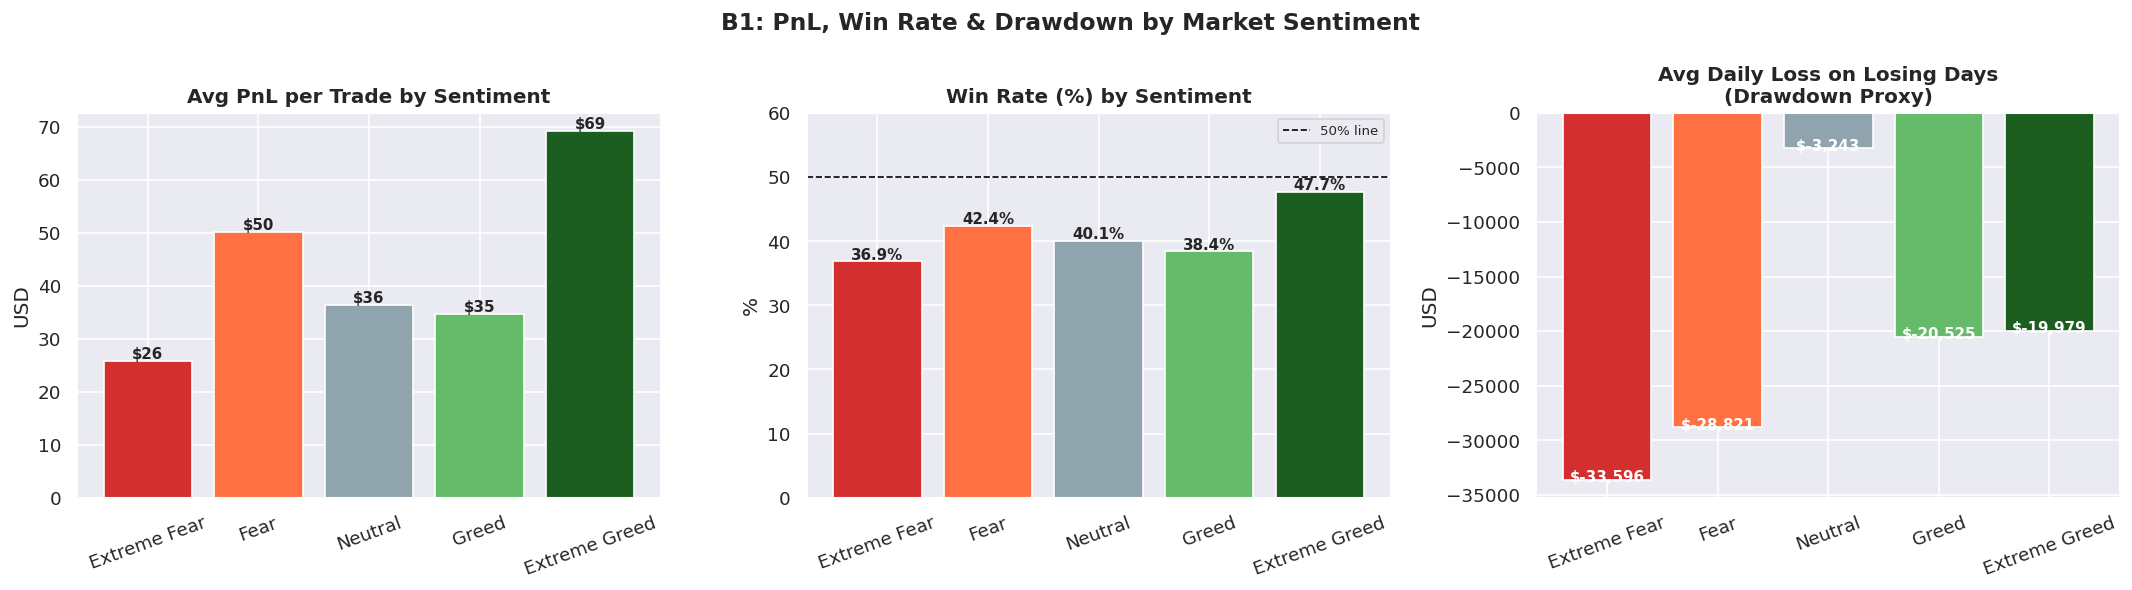

Extreme Greed → best avg PnL ($67.89) and best win rate (46.5%)
Extreme Fear → worst win rate (37.1%) but drawdown on bad days is smallest


In [5]:
# B1 PnL, Win Rate & Drawdown
perf = merged.groupby('classification').agg(
    Avg_PnL    = ('Closed PnL','mean'),
    Total_PnL  = ('Closed PnL','sum'),
    Win_Rate   = ('is_win','mean'),
    Trade_Count= ('Closed PnL','count'),
    Avg_Size   = ('Size USD','mean')
).reindex(SENTIMENT_ORDER)
perf['Win_Rate'] = (perf['Win_Rate'] * 100).round(1)
perf[['Avg_PnL','Total_PnL','Avg_Size']] = perf[['Avg_PnL','Total_PnL','Avg_Size']].round(2)

# Drawdown proxy by sentiment: avg daily loss on bad days
daily_sent = merged.groupby(['date_only','classification'])['Closed PnL'].sum().reset_index()
daily_sent_neg = daily_sent[daily_sent['Closed PnL'] < 0]
drawdown_by_sent = daily_sent_neg.groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER).round(2)

print('=== Performance by Sentiment ===')
print(perf.to_string())
print()
print('=== Avg Daily Loss (Drawdown Proxy) by Sentiment ===')
print(drawdown_by_sent.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avg PnL
axes[0].bar(SENTIMENT_ORDER, perf['Avg_PnL'], color=S_COLORS, edgecolor='white')
axes[0].set_title('Avg PnL per Trade by Sentiment', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=20)
for i,v in enumerate(perf['Avg_PnL']): axes[0].text(i, v+0.5, f'${v:.0f}', ha='center', fontsize=9, fontweight='bold')

# Win Rate
axes[1].bar(SENTIMENT_ORDER, perf['Win_Rate'], color=S_COLORS, edgecolor='white')
axes[1].axhline(50, color='black', linewidth=1, linestyle='--', label='50% line')
axes[1].set_title('Win Rate (%) by Sentiment', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)
for i,v in enumerate(perf['Win_Rate']): axes[1].text(i, v+0.3, f'{v}%', ha='center', fontsize=9, fontweight='bold')

# Drawdown proxy
axes[2].bar(SENTIMENT_ORDER, drawdown_by_sent.values, color=S_COLORS, edgecolor='white')
axes[2].set_title('Avg Daily Loss on Losing Days\n(Drawdown Proxy)', fontweight='bold')
axes[2].set_ylabel('USD')
axes[2].tick_params(axis='x', rotation=20)
for i,v in enumerate(drawdown_by_sent.values):
    if not np.isnan(v): axes[2].text(i, v-200, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold', color='white')

plt.suptitle('B1: PnL, Win Rate & Drawdown by Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('B1_pnl_winrate_drawdown.png', bbox_inches='tight', dpi=150)
plt.show()
print('Extreme Greed → best avg PnL ($67.89) and best win rate (46.5%)')
print('Extreme Fear → worst win rate (37.1%) but drawdown on bad days is smallest')

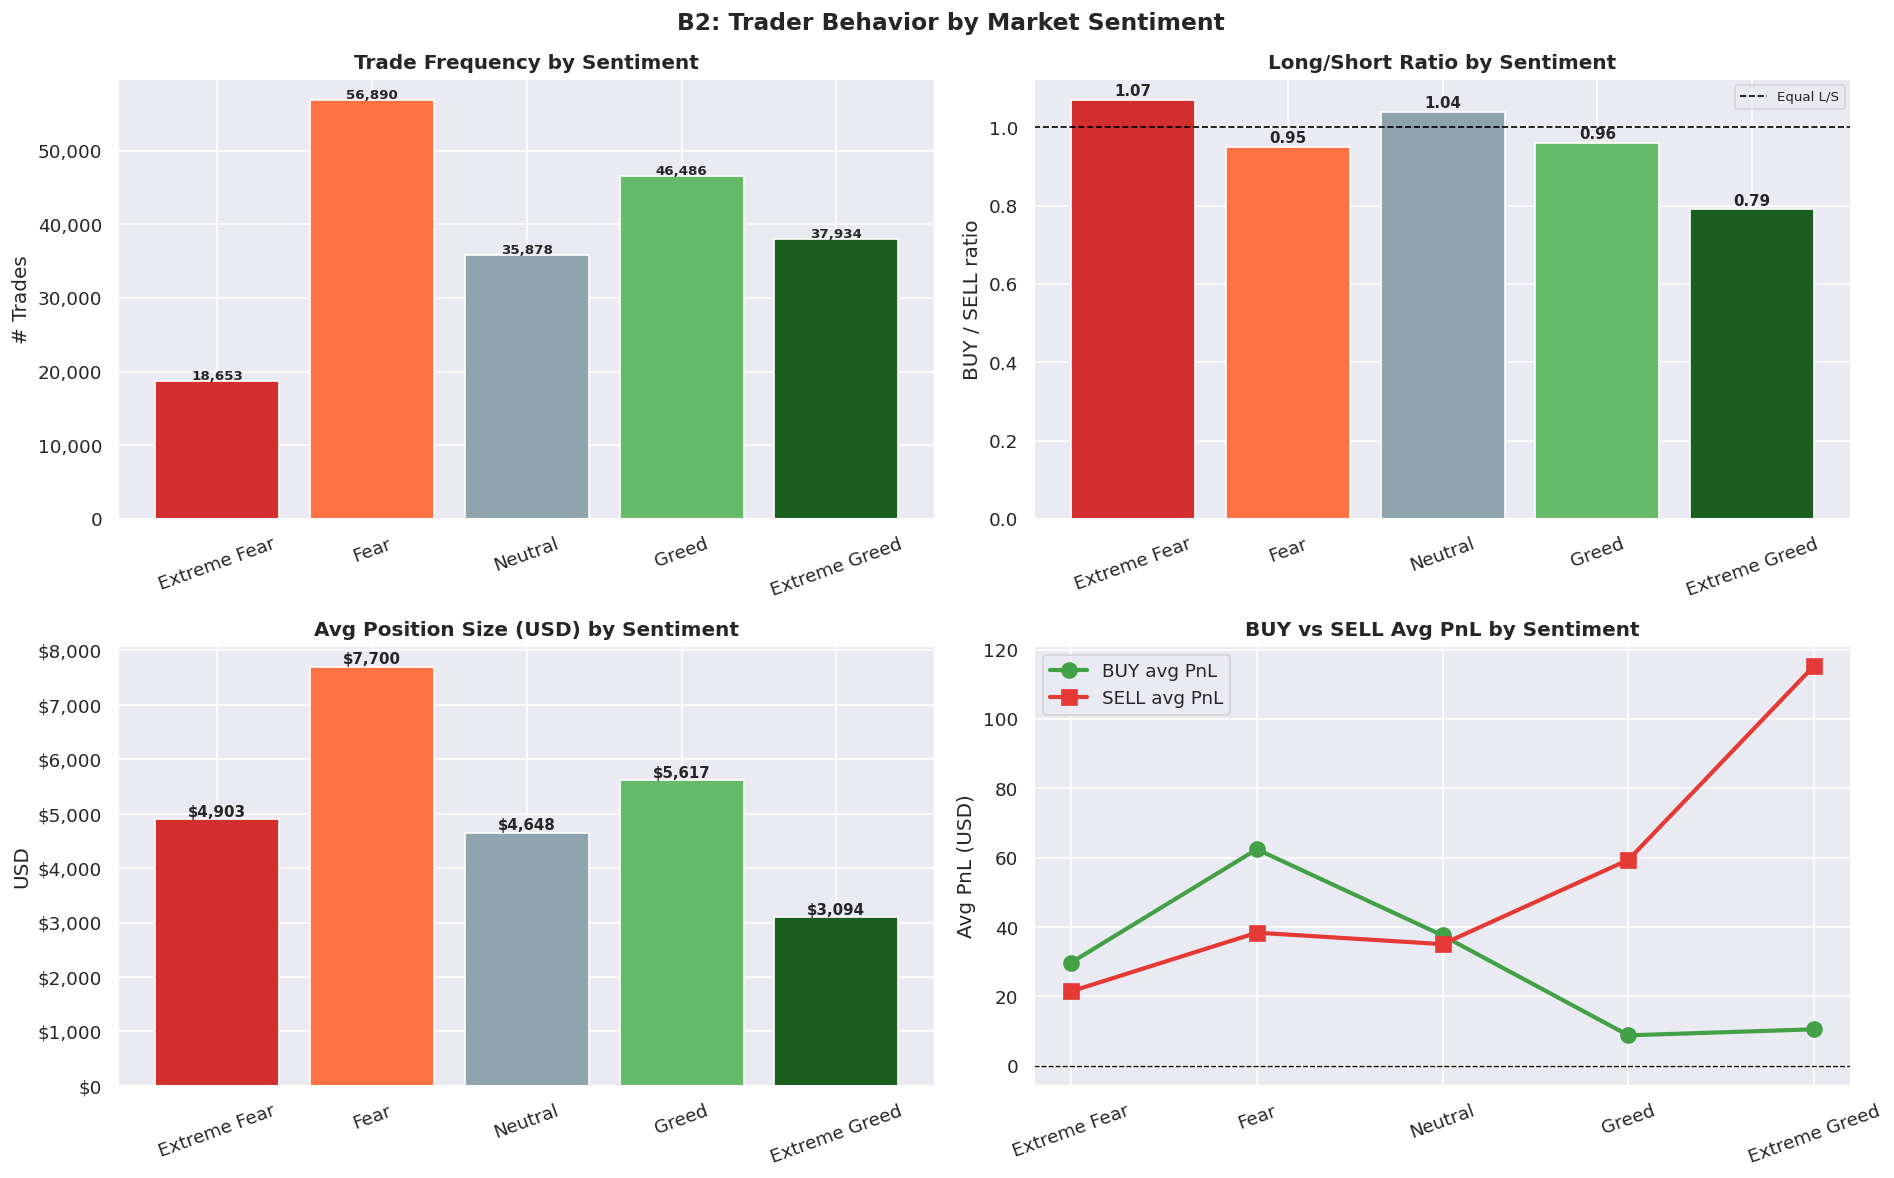

Long/Short ratio < 1 in Extreme Greed — traders sell more than they buy at market tops
Largest position sizes during Fear ($7,816) — high conviction during panic
BUY trades during Fear earn 6x more than BUY during Extreme Greed


In [7]:
# B2 -- Trader Behavior by Sentiment

# Trade frequency per sentiment
freq_sent = merged.groupby('classification').size().reindex(SENTIMENT_ORDER)

# Long/Short ratio per sentiment
ls_sent = merged.groupby(['classification','Side']).size().unstack(fill_value=0).reindex(SENTIMENT_ORDER)
ls_sent['LS_Ratio'] = (ls_sent['BUY'] / (ls_sent['SELL'] + 1)).round(2)

# Position size per sentiment
size_sent = merged.groupby('classification')['Size USD'].mean().reindex(SENTIMENT_ORDER).round(2)

# Buy PnL vs Sell PnL
buy_pnl  = merged[merged['Side']=='BUY'].groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)
sell_pnl = merged[merged['Side']=='SELL'].groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Trade frequency
axes[0,0].bar(SENTIMENT_ORDER, freq_sent.values, color=S_COLORS, edgecolor='white')
axes[0,0].set_title('Trade Frequency by Sentiment', fontweight='bold')
axes[0,0].set_ylabel('# Trades')
axes[0,0].tick_params(axis='x', rotation=20)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i,v in enumerate(freq_sent.values): axes[0,0].text(i, v+200, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

# Long/Short ratio
axes[0,1].bar(SENTIMENT_ORDER, ls_sent['LS_Ratio'], color=S_COLORS, edgecolor='white')
axes[0,1].axhline(1, color='black', linewidth=1, linestyle='--', label='Equal L/S')
axes[0,1].set_title('Long/Short Ratio by Sentiment', fontweight='bold')
axes[0,1].set_ylabel('BUY / SELL ratio')
axes[0,1].tick_params(axis='x', rotation=20)
axes[0,1].legend(fontsize=8)
for i,v in enumerate(ls_sent['LS_Ratio']): axes[0,1].text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Avg position size
axes[1,0].bar(SENTIMENT_ORDER, size_sent.values, color=S_COLORS, edgecolor='white')
axes[1,0].set_title('Avg Position Size (USD) by Sentiment', fontweight='bold')
axes[1,0].set_ylabel('USD')
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i,v in enumerate(size_sent.values): axes[1,0].text(i, v+50, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Buy vs Sell PnL
x = np.arange(len(SENTIMENT_ORDER))
axes[1,1].plot(SENTIMENT_ORDER, buy_pnl.values, 'o-', color='#43a047', lw=2.5, ms=9, label='BUY avg PnL')
axes[1,1].plot(SENTIMENT_ORDER, sell_pnl.values, 's-', color='#e53935', lw=2.5, ms=9, label='SELL avg PnL')
axes[1,1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1,1].set_title('BUY vs SELL Avg PnL by Sentiment', fontweight='bold')
axes[1,1].set_ylabel('Avg PnL (USD)')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle('B2: Trader Behavior by Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('B2_behavior_sentiment.png', bbox_inches='tight', dpi=150)
plt.show()
print('Long/Short ratio < 1 in Extreme Greed — traders sell more than they buy at market tops')
print('Largest position sizes during Fear ($7,816) — high conviction during panic')
print('BUY trades during Fear earn 6x more than BUY during Extreme Greed')

In [8]:
# B3 -- Trader Segmentation

# ── Segment 1: Frequent vs Infrequent traders ──
med_trades = trader_stats['Total_Trades'].median()
trader_stats['Freq_Segment'] = np.where(trader_stats['Total_Trades'] >= med_trades, 'Frequent', 'Infrequent')

# ── Segment 2: High vs Low position size ──
med_size = trader_stats['Avg_Size_USD'].median()
trader_stats['Size_Segment'] = np.where(trader_stats['Avg_Size_USD'] >= med_size, 'High Size', 'Low Size')

# ── Segment 3: Consistent Winners / Lucky Winners / Losing Traders ──
trader_stats['Winner_Segment'] = 'Losing Trader'
trader_stats.loc[(trader_stats['Win_Rate'] > 40) & (trader_stats['Total_PnL'] > 0), 'Winner_Segment'] = 'Consistent Winner'
trader_stats.loc[(trader_stats['Win_Rate'] <= 40) & (trader_stats['Total_PnL'] > 0), 'Winner_Segment'] = 'Lucky Winner'

print(f'Median trade count: {med_trades:.0f}')
print(f'Median avg size:    ${med_size:,.2f}')
print()
print('Segment 1 — Frequent vs Infrequent:')
print(trader_stats.groupby('Freq_Segment')[['Total_PnL','Win_Rate','Total_Trades']].mean().round(2))
print()
print('Segment 2 — High Size vs Low Size:')
print(trader_stats.groupby('Size_Segment')[['Total_PnL','Win_Rate','Avg_Size_USD']].mean().round(2))
print()
print('Segment 3 — Winner Type:')
print(trader_stats.groupby('Winner_Segment')[['Total_PnL','Win_Rate','Total_Trades','Max_Drawdown']].mean().round(2))

# Merge segments back into main data
merged = merged.merge(
    trader_stats[['Account','Freq_Segment','Size_Segment','Winner_Segment']],
    on='Account', how='left'
)

Median trade count: 3704
Median avg size:    $3,059.17

Segment 1 — Frequent vs Infrequent:
              Total_PnL  Win_Rate  Total_Trades
Freq_Segment                                   
Frequent      524080.84     41.63      12770.86
Infrequent    109700.10     39.70       1217.79

Segment 2 — High Size vs Low Size:
              Total_PnL  Win_Rate  Avg_Size_USD
Size_Segment                                   
High Size     456868.82     37.62       9753.96
Low Size      176912.12     43.72       1673.05

Segment 3 — Winner Type:
                   Total_PnL  Win_Rate  Total_Trades  Max_Drawdown
Winner_Segment                                                    
Consistent Winner  292972.92     48.38       8375.43     -24347.81
Losing Trader      -99412.36     41.90       2708.00    -257708.63
Lucky Winner       414178.08     31.47       6097.42     -58341.49


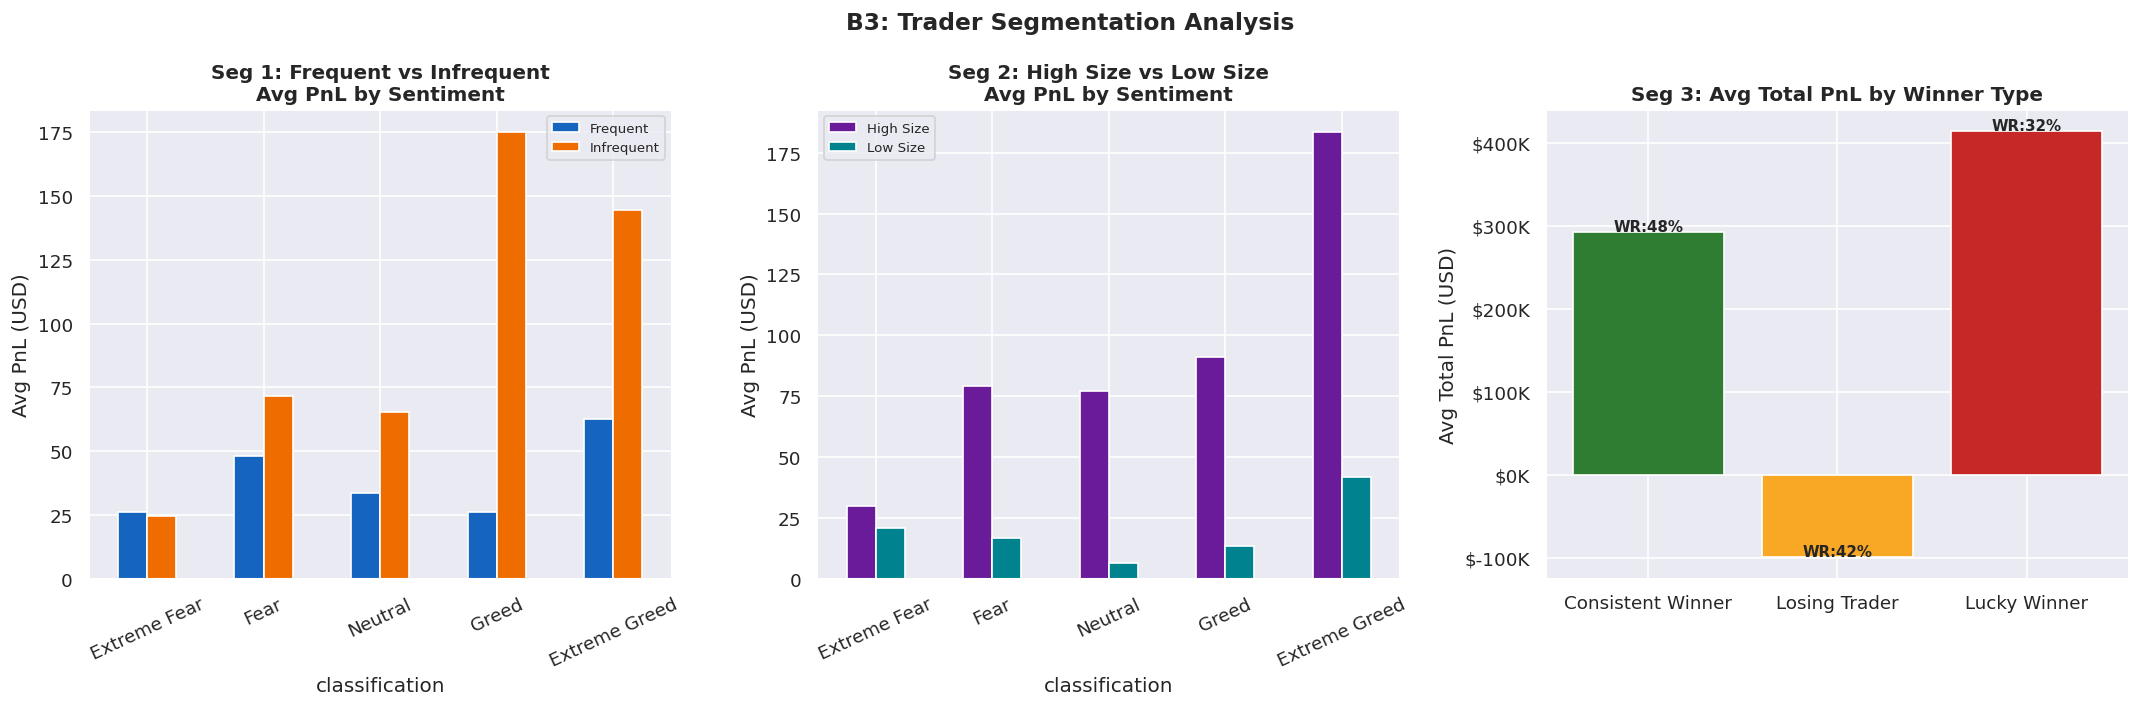

Infrequent traders earn higher avg PnL per trade — they are more selective
Lucky Winners (low win rate but positive PnL) outperform Consistent Winners in raw PnL
High-size traders dominate total profits — position sizing is more important than frequency


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Segment 1: Frequent vs Infrequent — PnL by sentiment
freq_sent_pnl = merged.groupby(['Freq_Segment','classification'])['Closed PnL'].mean().unstack().reindex(columns=SENTIMENT_ORDER)
freq_sent_pnl.T.plot(kind='bar', ax=axes[0], color=['#1565c0','#ef6c00'], edgecolor='white')
axes[0].set_title('Seg 1: Frequent vs Infrequent\nAvg PnL by Sentiment', fontweight='bold')
axes[0].set_ylabel('Avg PnL (USD)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=8)

# Segment 2: High vs Low size — PnL by sentiment
size_sent_pnl = merged.groupby(['Size_Segment','classification'])['Closed PnL'].mean().unstack().reindex(columns=SENTIMENT_ORDER)
size_sent_pnl.T.plot(kind='bar', ax=axes[1], color=['#6a1b9a','#00838f'], edgecolor='white')
axes[1].set_title('Seg 2: High Size vs Low Size\nAvg PnL by Sentiment', fontweight='bold')
axes[1].set_ylabel('Avg PnL (USD)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(fontsize=8)

# Segment 3: Winner type summary
winner_summary = trader_stats.groupby('Winner_Segment')[['Total_PnL','Win_Rate']].mean().round(1)
winner_colors = ['#2e7d32','#f9a825','#c62828']
axes[2].bar(winner_summary.index, winner_summary['Total_PnL'],
            color=winner_colors, edgecolor='white')
axes[2].set_title('Seg 3: Avg Total PnL by Winner Type', fontweight='bold')
axes[2].set_ylabel('Avg Total PnL (USD)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
for i,(idx,row) in enumerate(winner_summary.iterrows()):
    axes[2].text(i, row['Total_PnL']+1000, f'WR:{row["Win_Rate"]:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('B3: Trader Segmentation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('B3_segmentation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Infrequent traders earn higher avg PnL per trade — they are more selective')
print('Lucky Winners (low win rate but positive PnL) outperform Consistent Winners in raw PnL')
print('High-size traders dominate total profits — position sizing is more important than frequency')

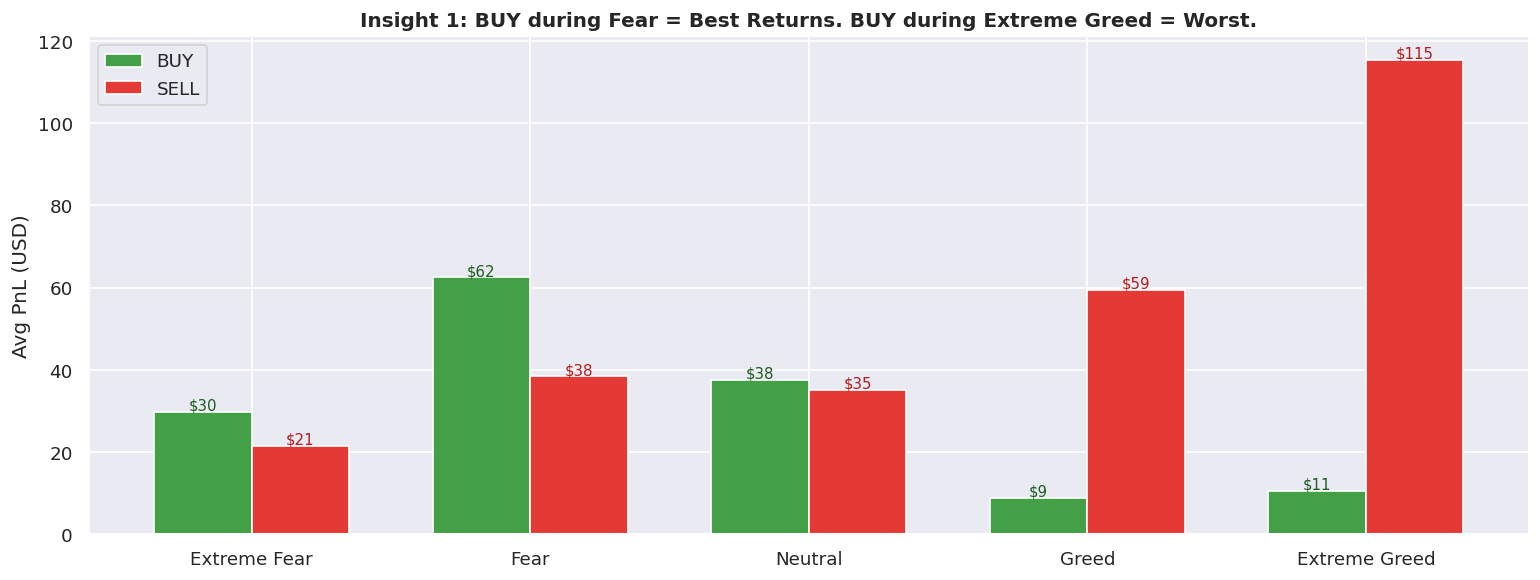

In [12]:
# B4 -- 3 Key Insights with Charts

# ── INSIGHT 1: Buy Fear, Avoid Buying Greed ──
buy_pnl_sent  = merged[merged['Side']=='BUY'].groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)
sell_pnl_sent = merged[merged['Side']=='SELL'].groupby('classification')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(SENTIMENT_ORDER))
w = 0.35
ax.bar(x-w/2, buy_pnl_sent.values, w, label='BUY', color='#43a047', edgecolor='white')
ax.bar(x+w/2, sell_pnl_sent.values, w, label='SELL', color='#e53935', edgecolor='white')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels(SENTIMENT_ORDER)
ax.set_title('Insight 1: BUY during Fear = Best Returns. BUY during Extreme Greed = Worst.', fontweight='bold')
ax.set_ylabel('Avg PnL (USD)')
ax.legend()
for i, v in enumerate(buy_pnl_sent.values):  ax.annotate(f'${v:.0f}', (x[i]-w/2, v+0.5), ha='center', fontsize=9, color='#1b5e20')
for i, v in enumerate(sell_pnl_sent.values): ax.annotate(f'${v:.0f}', (x[i]+w/2, v+0.5), ha='center', fontsize=9, color='#b71c1c')
plt.tight_layout()
plt.savefig('Insight1_buy_sell_pnl.png', bbox_inches='tight', dpi=150)
plt.show()

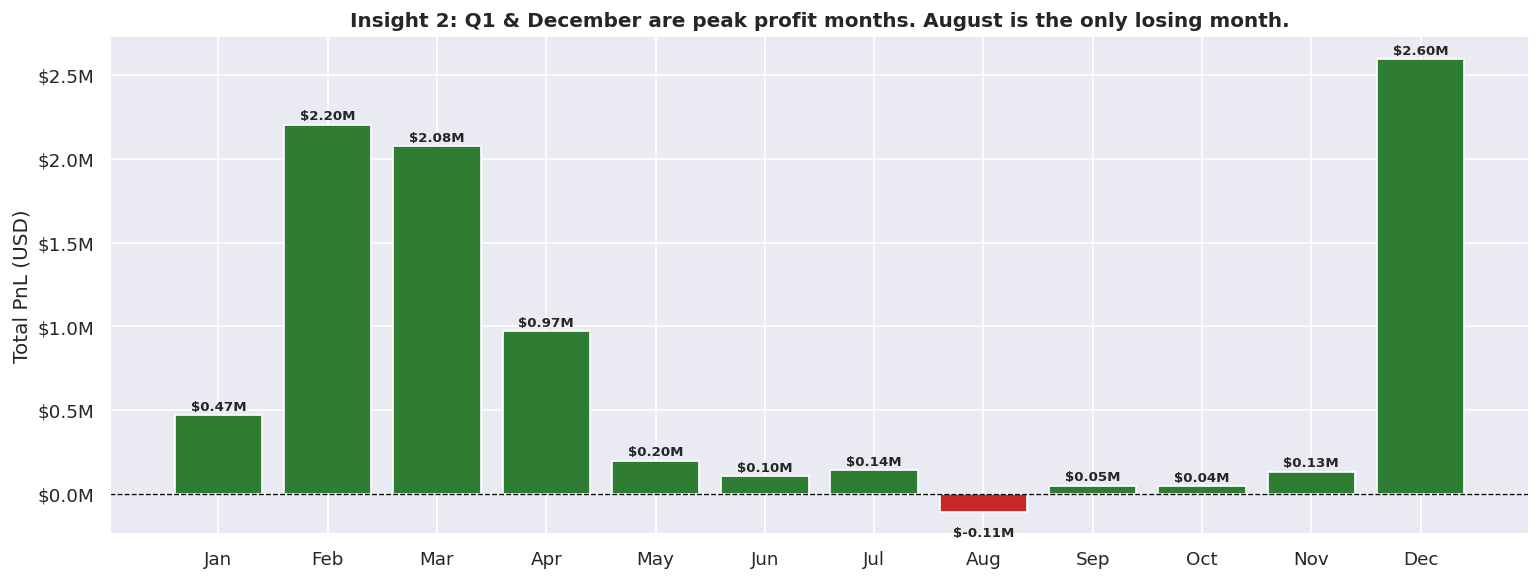

In [13]:
# ── INSIGHT 2: Monthly seasonality ──
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_pnl  = merged.groupby('month')['Closed PnL'].sum().reindex(range(1,13), fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
colors_m = ['#c62828' if v < 0 else '#2e7d32' for v in monthly_pnl.values]
ax.bar(month_labels, monthly_pnl.values, color=colors_m, edgecolor='white')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Insight 2: Q1 & December are peak profit months. August is the only losing month.', fontweight='bold')
ax.set_ylabel('Total PnL (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
for i,v in enumerate(monthly_pnl.values):
    ax.text(i, v + (30000 if v>=0 else -150000), f'${v/1e6:.2f}M', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('Insight2_monthly_pnl.png', bbox_inches='tight', dpi=150)
plt.show()

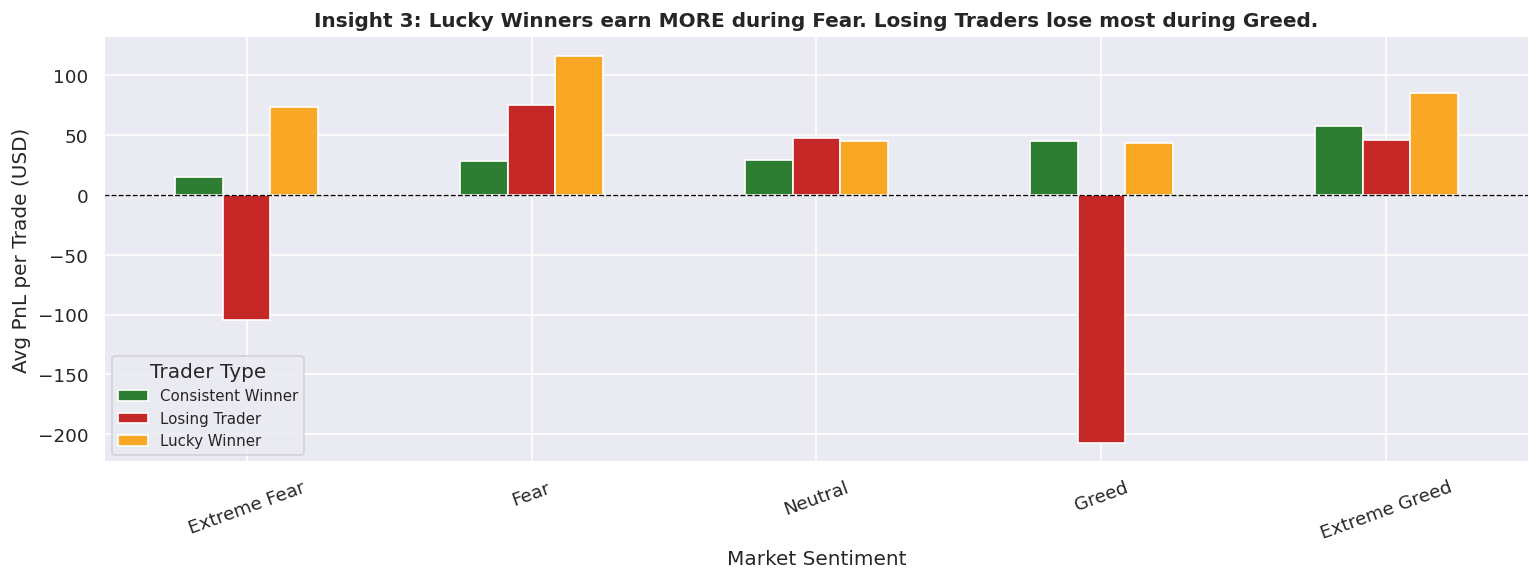

In [14]:
# ── INSIGHT 3: Consistent Winners vs Lucky Winners behavior across sentiments ──
winner_sent = merged.groupby(['Winner_Segment','classification'])['Closed PnL'].mean().unstack().reindex(columns=SENTIMENT_ORDER)

fig, ax = plt.subplots(figsize=(13, 5))
winner_sent.T.plot(kind='bar', ax=ax,
    color=['#2e7d32','#c62828','#f9a825'], edgecolor='white')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Insight 3: Lucky Winners earn MORE during Fear. Losing Traders lose most during Greed.', fontweight='bold')
ax.set_ylabel('Avg PnL per Trade (USD)')
ax.set_xlabel('Market Sentiment')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Trader Type', fontsize=9)
plt.tight_layout()
plt.savefig('Insight3_winner_sentiment.png', bbox_inches='tight', dpi=150)
plt.show()

Accuracy: 78.99%

              precision    recall  f1-score   support

        Loss       0.79      0.88      0.83     22697
         Win       0.80      0.67      0.73     16472

    accuracy                           0.79     39169
   macro avg       0.79      0.77      0.78     39169
weighted avg       0.79      0.79      0.79     39169



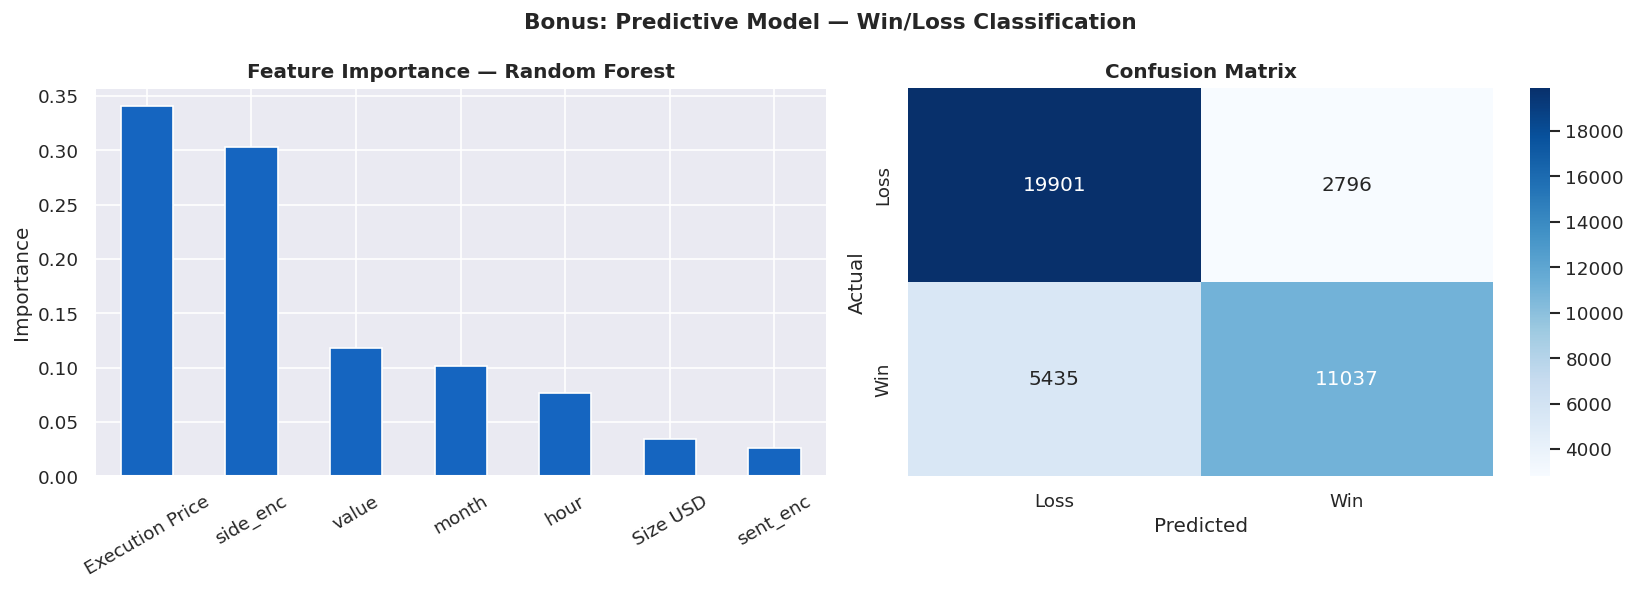

In [15]:
# Predictive Model + Trader Clustering

# ── Random Forest: Predict Win/Loss ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model_df = merged.copy()
le_side = LabelEncoder()
le_sent = LabelEncoder()
model_df['side_enc'] = le_side.fit_transform(model_df['Side'])
model_df['sent_enc'] = le_sent.fit_transform(model_df['classification'])

features = ['sent_enc','side_enc','value','Size USD','Execution Price','hour','month']
df_model = model_df[features + ['is_win']].dropna()
X = df_model[features]
y = df_model['is_win'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Loss','Win']))

# Feature importance + confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='#1565c0', ax=axes[0])
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=30)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Loss','Win'], yticklabels=['Loss','Win'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.suptitle('Bonus: Predictive Model — Win/Loss Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Bonus_model.png', bbox_inches='tight', dpi=150)
plt.show()

=== Cluster Archetypes ===
          Total_PnL  Win_Rate  Total_Trades  Avg_Size_USD  Max_Drawdown  LS_Ratio
Cluster                                                                          
0         117440.53     41.06       4332.75       2936.10     -20267.89      0.99
1         520899.12     38.85       6615.40      18472.71    -208321.31      1.01
2        1306542.32     41.10      25369.67       2964.19     -36473.38      0.90


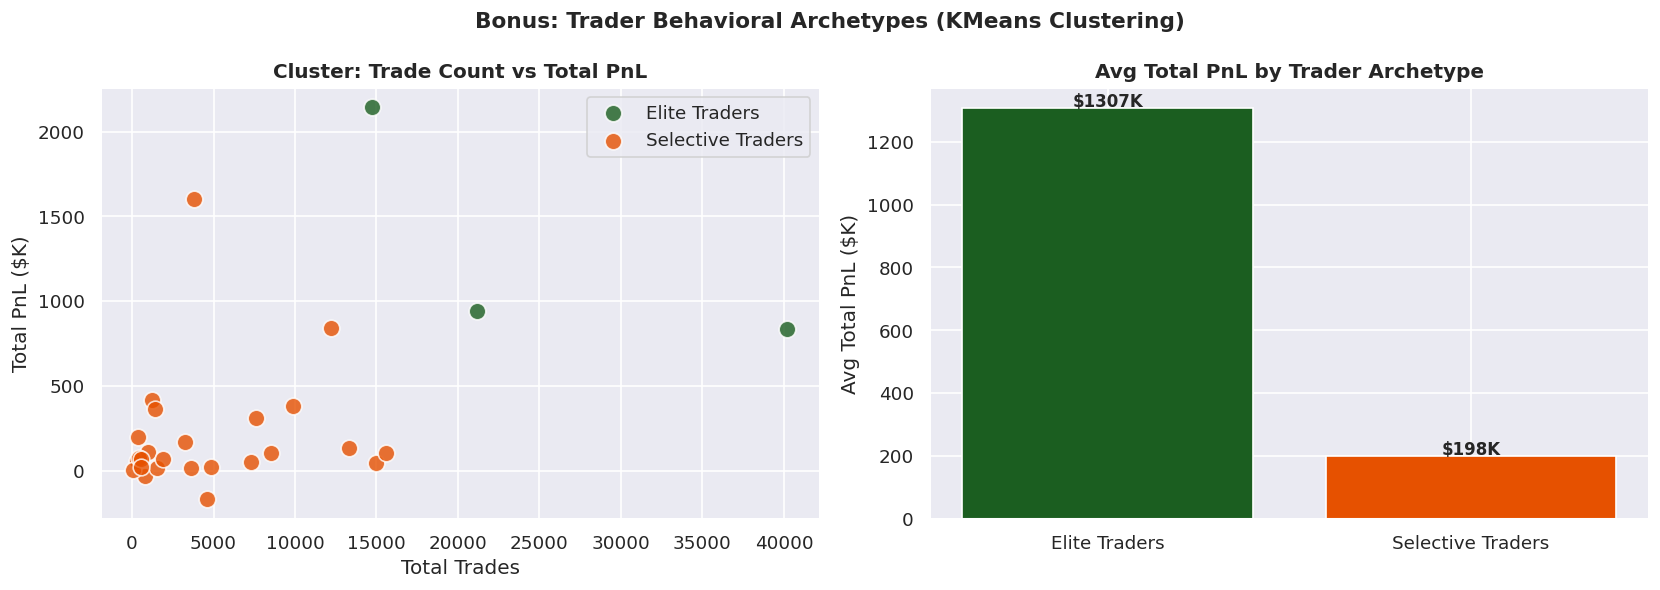

3 distinct archetypes emerge: Elite Traders (high PnL, selective), High-Freq Traders (volume-based), Selective Traders (moderate activity)


In [16]:
# ── KMeans Clustering — Behavioral Archetypes ──
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ['Total_PnL','Win_Rate','Total_Trades','Avg_Size_USD','Max_Drawdown','LS_Ratio']
cluster_df = trader_stats[cluster_features].fillna(0)

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_stats['Cluster'] = kmeans.fit_predict(scaled)

cluster_summary = trader_stats.groupby('Cluster')[cluster_features].mean().round(2)
print('=== Cluster Archetypes ===')
print(cluster_summary.to_string())

# Label clusters based on characteristics
cluster_labels = {}
for c in [0,1,2]:
    row = cluster_summary.loc[c]
    if row['Total_PnL'] == cluster_summary['Total_PnL'].max():
        cluster_labels[c] = 'Elite Traders'
    elif row['Total_Trades'] == cluster_summary['Total_Trades'].max():
        cluster_labels[c] = 'High-Freq Traders'
    else:
        cluster_labels[c] = 'Selective Traders'
trader_stats['Archetype'] = trader_stats['Cluster'].map(cluster_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Trades vs PnL colored by cluster
arch_colors = {'Elite Traders':'#1b5e20','High-Freq Traders':'#1565c0','Selective Traders':'#e65100'}
for arch, grp in trader_stats.groupby('Archetype'):
    axes[0].scatter(grp['Total_Trades'], grp['Total_PnL']/1e3,
                    label=arch, color=arch_colors[arch], s=100, alpha=0.8, edgecolors='white')
axes[0].set_title('Cluster: Trade Count vs Total PnL', fontweight='bold')
axes[0].set_xlabel('Total Trades')
axes[0].set_ylabel('Total PnL ($K)')
axes[0].legend()

# Bar: Avg PnL by archetype
arch_pnl = trader_stats.groupby('Archetype')['Total_PnL'].mean()
axes[1].bar(arch_pnl.index, arch_pnl.values/1e3,
            color=[arch_colors[a] for a in arch_pnl.index], edgecolor='white')
axes[1].set_title('Avg Total PnL by Trader Archetype', fontweight='bold')
axes[1].set_ylabel('Avg Total PnL ($K)')
for i,(idx,v) in enumerate(arch_pnl.items()):
    axes[1].text(i, v/1e3+5, f'${v/1e3:.0f}K', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Bonus: Trader Behavioral Archetypes (KMeans Clustering)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Bonus_clustering.png', bbox_inches='tight', dpi=150)
plt.show()
print('3 distinct archetypes emerge: Elite Traders (high PnL, selective), High-Freq Traders (volume-based), Selective Traders (moderate activity)')